# Decision Tree Build

Attempting to build the decision tree using entropy score


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import seaborn as sns

from ml_world_cup_predictor.data_transformation import transform_match_data 
from ml_world_cup_predictor.feature_engineering import generate_match_features
from ml_world_cup_predictor.plot_theme import apply_theme, set_titles
from ml_world_cup_predictor.config import WC_START

apply_theme()

# Loading and Build Working Dataset for Decision Tree
played, _ = transform_match_data()

played_with_features = generate_match_features(played)


c:\Users\eoinm\Documents\ml_world_cup_predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cached dataset at: C:\Users\eoinm\Documents\ml_world_cup_predictor\data\international-football-results


Cutting off the active dateset to only include pre World Cup matches

In [2]:
wc_match = played_with_features[(played_with_features.date >= WC_START) & (played_with_features.tournament == 'FIFA World Cup')]
full_df = played_with_features[(played_with_features.date < WC_START)]

wc_match

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,shootout_id,shootout_winner,year,result,goal_diff,home_elo,away_elo,elo_difference,home_form,away_form,form_difference
48756,2026-06-11,Mexico,South Africa,2.0,0.0,FIFA World Cup,Mexico City,Mexico,False,2026-06-11_Mexico_South Africa,NaN,2026,W,2.0,2144.463506,1710.117865,434.345641,0.400000,0.333333,0.066667
48757,2026-06-11,South Korea,Czech Republic,2.0,1.0,FIFA World Cup,Zapopan,Mexico,True,2026-06-11_South Korea_Czech Republic,NaN,2026,W,1.0,2006.289464,2004.601207,1.688258,0.266667,0.133333,0.133333
48758,2026-06-12,Canada,Bosnia and Herzegovina,1.0,1.0,FIFA World Cup,Toronto,Canada,False,2026-06-12_Canada_Bosnia and Herzegovina,NaN,2026,D,0.0,2061.450648,1869.676491,191.774157,0.466667,0.333333,0.133333
48759,2026-06-12,United States,Paraguay,4.0,1.0,FIFA World Cup,Inglewood,United States,False,2026-06-12_United States_Paraguay,NaN,2026,W,3.0,1973.461107,2137.758297,-164.297190,0.066667,0.266667,-0.200000
48760,2026-06-13,Qatar,Switzerland,1.0,1.0,FIFA World Cup,Santa Clara,United States,True,2026-06-13_Qatar_Switzerland,NaN,2026,D,0.0,1555.240208,2173.055470,-617.815263,0.333333,0.333333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48847,2026-07-05,Mexico,England,2.0,3.0,FIFA World Cup,Mexico City,Mexico,False,2026-07-05_Mexico_England,NaN,2026,L,1.0,2336.832602,2450.376945,-113.544343,0.266667,0.133333,0.133333
48848,2026-07-06,Portugal,Spain,0.0,1.0,FIFA World Cup,Dallas,United States,True,2026-07-06_Portugal_Spain,NaN,2026,L,1.0,2364.596162,2566.509969,-201.913807,0.266667,0.266667,0.000000
48849,2026-07-06,United States,Belgium,1.0,4.0,FIFA World Cup,Seattle,United States,False,2026-07-06_United States_Belgium,NaN,2026,L,3.0,2172.861566,2248.877303,-76.015737,0.066667,0.333333,-0.266667
48850,2026-07-07,Argentina,Egypt,3.0,2.0,FIFA World Cup,Atlanta,United States,True,2026-07-07_Argentina_Egypt,NaN,2026,W,1.0,2493.240493,2081.458269,411.782223,0.066667,0.266667,-0.200000


## Distribution By Outcome

Compare distribution of the different features 

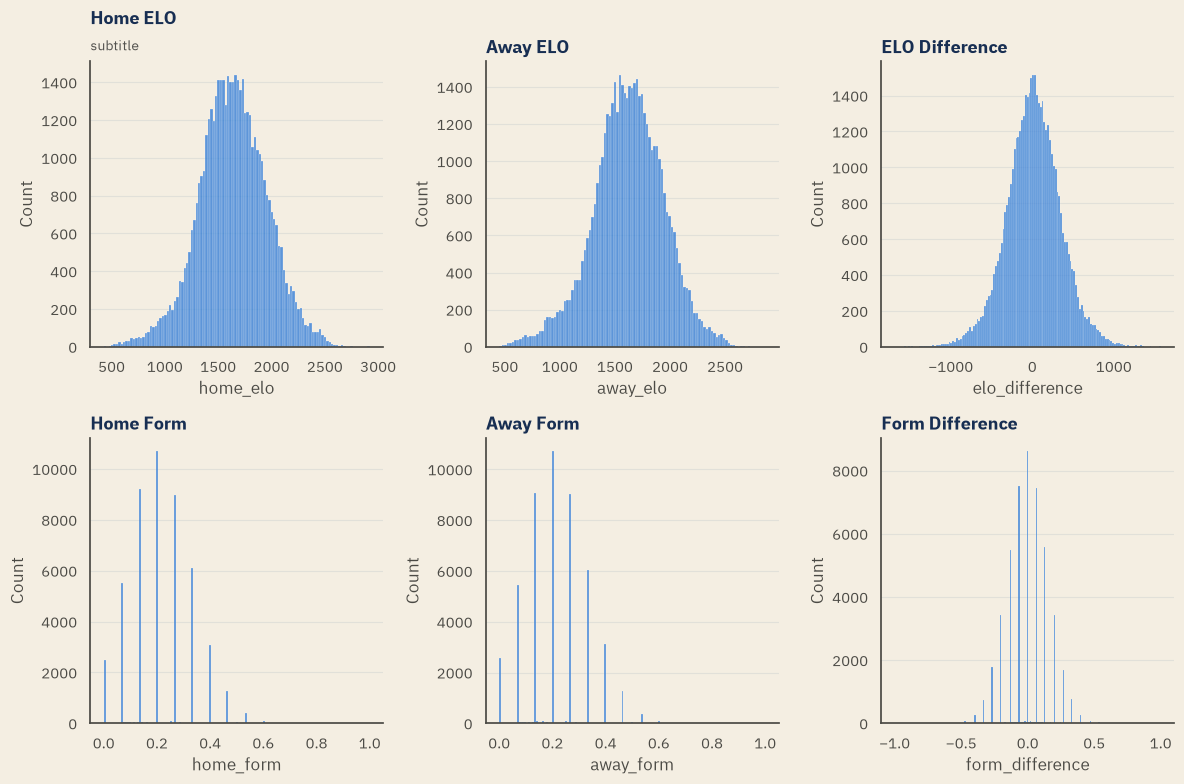

In [3]:
full_df.tail(20)

#full_df['elo_difference'] = full_df['home_elo'] - full_df['away_elo']
#full_df['form_difference'] = full_df['home_form'] - full_df['away_form']

features = ['home_elo','away_elo','home_form','away_form']

fig, axes = plt.subplots(nrows = 2, ncols = 3,figsize = (12,8))
ax1 ,ax2, ax3, ax4, ax5, ax6 = axes.flatten()
sns.histplot(full_df['home_elo'], ax= ax1)
set_titles(ax1,'Home ELO','subtitle')
#ax1.set_title('Home ELO')
sns.histplot(full_df['away_elo'], ax= ax2)
ax2.set_title('Away ELO')
sns.histplot(full_df['elo_difference'], ax= ax3)
ax3.set_title('ELO Difference')
sns.histplot(full_df['home_form'], ax= ax4)
ax4.set_title('Home Form')
sns.histplot(full_df['away_form'], ax= ax5)
ax5.set_title('Away Form')
sns.histplot(full_df['form_difference'], ax= ax6)
ax6.set_title('Form Difference')
plt.tight_layout()


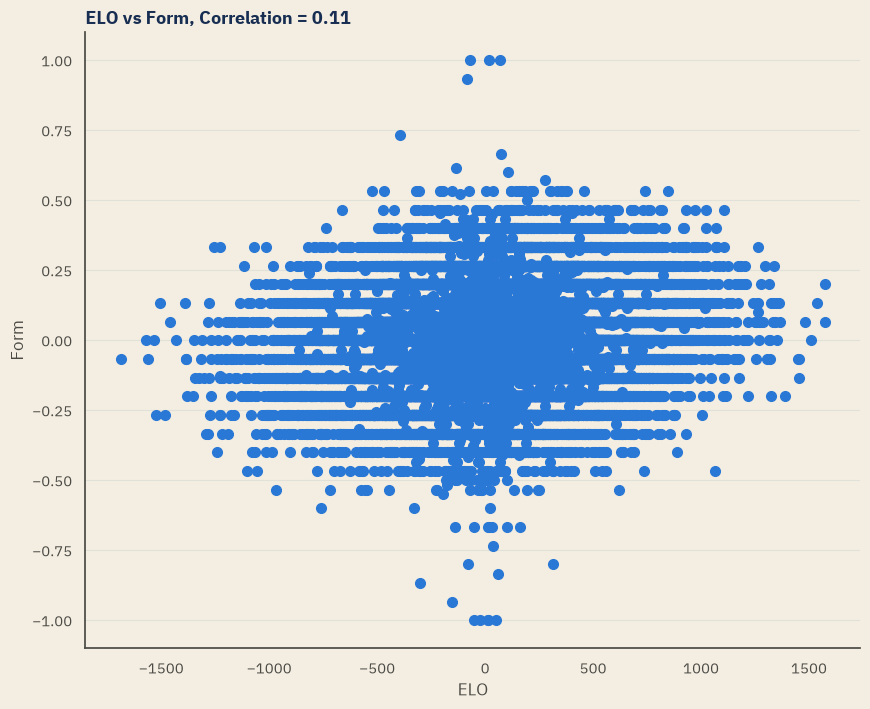

In [4]:
fig, ax = plt.subplots(figsize = (10,8))

plt.scatter(full_df['elo_difference'],full_df['form_difference'])
plt.xlabel('ELO')
plt.ylabel('Form')
cor = full_df['elo_difference'].corr(full_df['form_difference'])
set_titles(ax, title=f'ELO vs Form, Correlation = {cor:.2f}')


In [5]:


def violin_plot_df(df,feature_list,ax,feature_name = 'features',value_name = 'values'):

    df = df.copy()

    df_melt = pd.melt(
        df,
        id_vars= ['result'],
        value_vars = feature_list,
        var_name= feature_name,
        value_name= value_name
    )

    sns.violinplot(
    data = df_melt,
    x =feature_name,
    y = value_name,
    hue = 'result',
    ax= ax
)

played_long = pd.melt(
    full_df,
    id_vars = ['result'],
    value_vars = features,
    var_name = 'features',
    value_name = 'value'
)


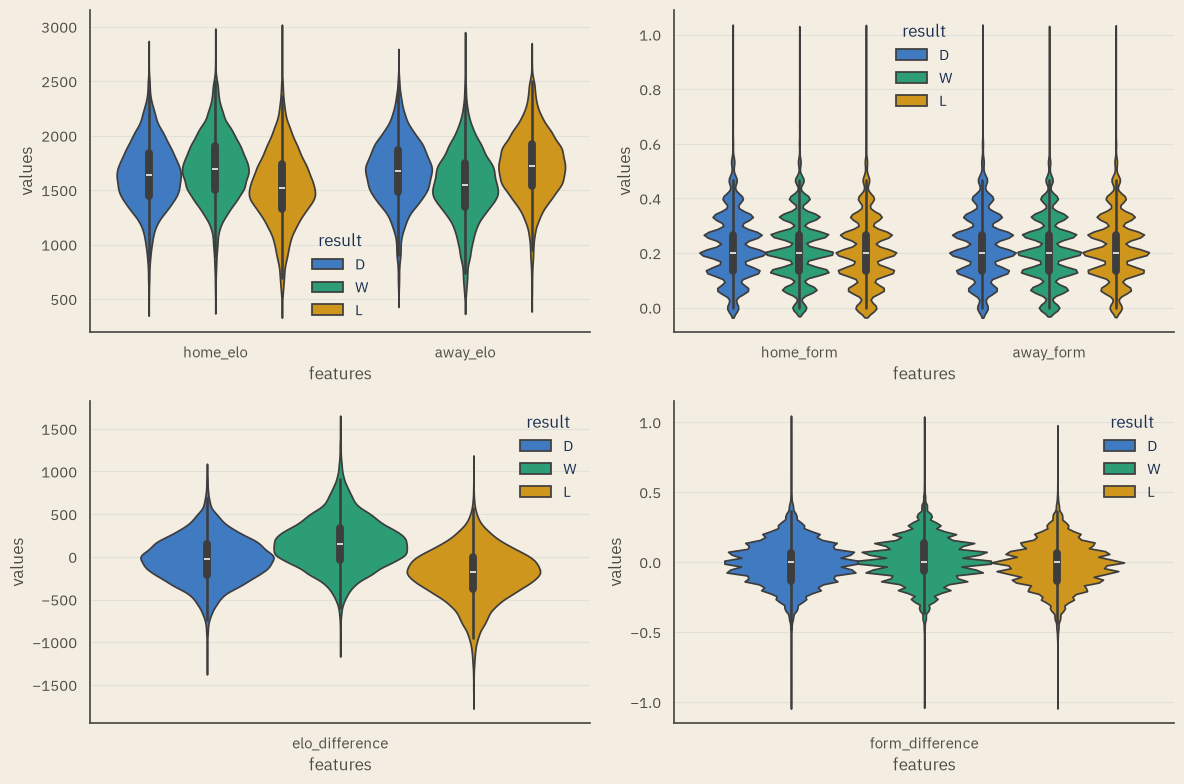

In [6]:
fig, axes = plt.subplots(nrows= 2, ncols=2, figsize = (12,8))

ax1, ax2, ax3, ax4 = axes.flatten()

violin_plot_df(full_df,['home_elo','away_elo'],ax1)
violin_plot_df(full_df,['home_form','away_form'],ax2)
violin_plot_df(full_df,['elo_difference'],ax3)
violin_plot_df(full_df,['form_difference'],ax4)

plt.tight_layout()



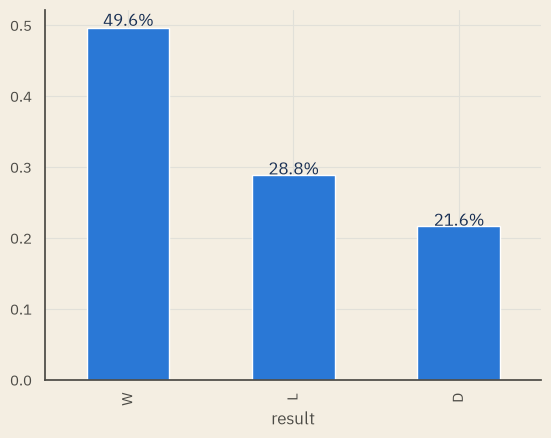

In [7]:
ax = full_df['result'].value_counts(normalize = True).plot(kind = 'bar')
for p in ax.patches:
    ax.annotate(f'{(p.get_height())*100:.1f}%',(p.get_x()+0.1,p.get_height()*1.005))

In [8]:

for col in full_df.columns:

    na_count = full_df[col].isna().sum()
    na_pct = 100*(na_count / len(full_df))
    print(f'Null Count in {col} is {na_count} ({na_pct:.2f}%)')

clean_df = full_df[~(full_df['form_difference'].isna())]


Null Count in date is 0 (0.00%)
Null Count in home_team is 0 (0.00%)
Null Count in away_team is 0 (0.00%)
Null Count in home_score is 0 (0.00%)
Null Count in away_score is 0 (0.00%)
Null Count in tournament is 0 (0.00%)
Null Count in city is 0 (0.00%)
Null Count in country is 0 (0.00%)
Null Count in neutral is 0 (0.00%)
Null Count in shootout_id is 0 (0.00%)
Null Count in shootout_winner is 48112 (98.68%)
Null Count in year is 0 (0.00%)
Null Count in result is 0 (0.00%)
Null Count in goal_diff is 0 (0.00%)
Null Count in home_elo is 0 (0.00%)
Null Count in away_elo is 0 (0.00%)
Null Count in elo_difference is 0 (0.00%)
Null Count in home_form is 104 (0.21%)
Null Count in away_form is 143 (0.29%)
Null Count in form_difference is 217 (0.45%)


In [9]:
# Update df with just features 
features = ['result','form_difference','elo_difference']
final_df = clean_df[features]

# Manually create my own training / test split
def split_data(df,ratio = 0.80):

    total_rows = len(df)
    train_size = int(total_rows*ratio)


    train = df[0:train_size]
    test = df[train_size:]

    return train,test


train, test = split_data(final_df)
dfs = {'train':train,'test':test}
print(f'Training Rows = {len(train):,}')
print(f'Test Rows = {len(test):,}')

train.head()


Training Rows = 38,831
Test Rows = 9,708


,result,form_difference,elo_difference
1,W,0.000000,5.602600
2,W,0.000000,-47.907277
3,D,0.000000,13.860132
4,W,0.000000,-7.530795
6,L,0.066667,-84.309767


In [ ]:
## Building entropy Score Function
def entropy(class_counts,total):

    if total == 0:
        return 0
    
    result = 0

    for count in class_counts:
        if count == 0:
            continue

        p = count/total
        result -= p * np.log2(p)
    
    return result


def find_best_threshold(feature,y):

    # Paring up each feature value with corresponding label and sorting by value
    paired = sorted(zip(feature,y))

    # Full Length of the data
    n = len(y)

    # The counts when the filter is at the furthest left of the data
    labels, counts = np.unique(y,return_counts=True)
    right_count = dict(zip(labels,counts))
    left_count = {label: 0 for label in labels}

    # Initialised before the for loop
    best_gain = -1
    best_threshold = None


    parent_entropy = entropy(right_count.values(),n)

    # Iterate over the index of the data
    for i in range(n-1):

        # Get the current data and label
        value_i, label_i = paired[i]

        # Increment the left count of whatever label is at this index as we move the parition to the right of it
        left_count[label_i] += 1
        # Reduce the right count at this index as this label goes to the lift of the partition 
        right_count[label_i] -= 1

        # Identify the next value and label
        value_next,label_next = paired[i+1]

        # If there is no change in class continue because .....
        if label_i == label_next:
            continue
        
        # Calculate the total size of both sides
        n_left = i + 1
        n_right = n - n_left

        # Calculate the entropy for each child node
        left_entropy = entropy(left_count.values(),n_left)
        right_entropy = entropy(right_count.values(),n_right)

        information_gain = parent_entropy - (n_left/n)*left_entropy - (n_right/n)*right_entropy

        if information_gain > best_gain:
            best_gain = information_gain
            
            best_threshold = (value_i + value_next)/2
        
    return best_threshold,best_gain



In [11]:

MINIMUM_ENTROPY = 0.05
SAMPLES_PER_SPLIT = 50

In [12]:

## Applying the Entropy to each column, basing the split threshold on median
def find_best_split(df,y_col):

    X = df.loc[:,df.columns != y_col]
    y = df[y_col]
    
    optimal ={
        'feature':None,
        'info_gain': -1,
        'threshold':0
    }
    for column in X.columns:
        
        if column == 'result':
            continue
        
        else:
            best_threshold, best_gain = find_best_threshold(X[column],y)
            
            if best_gain > optimal['info_gain']:
                optimal['feature'] = column
                optimal['info_gain'] = best_gain
                optimal['threshold'] = best_threshold

    return optimal


def generate_split(df,optimal_split):

    child_left = df[df[optimal_split['feature']] < optimal_split['threshold']]
    child_right = df[df[optimal_split['feature']] >= optimal_split['threshold']]

    return child_left,child_right



In [13]:
X = train.loc[:,train.columns != 'result']
y = train['result']
#optimal_split = find_best_split(X,y)
optimal_split = find_best_split(train,'result')


child_left = train[train[optimal_split['feature']] < optimal_split['threshold']]
child_right = train[train[optimal_split['feature']] >= optimal_split['threshold']]

print(f'Left Node = {len(child_left):,}, Right Node = {len(child_right):,}')
print(optimal_split)



Left Node = 17,702, Right Node = 21,129
{'feature': 'elo_difference', 'info_gain': np.float64(0.10873820120911382), 'threshold': -22.449493934727684}


In [14]:

child_left, child_right = generate_split(train,optimal_split)

print(f'Left Node = {len(child_left):,}, Right Node = {len(child_right):,}')
print(optimal_split)

print(child_right['result'].value_counts().idxmax())


Left Node = 17,702, Right Node = 21,129
{'feature': 'elo_difference', 'info_gain': np.float64(0.10873820120911382), 'threshold': -22.449493934727684}
W


In [15]:
MAX_DEPTH = 5

class Node:

    def __init__(self,left=None,right=None,split=None,value=None):

        self.left = left
        self.right = right
        self.split = split
        self.value = value
    
    def is_leaf(self):
        return self.value is not None 

def recursive_split(df,y_col,splits = 0):

    if splits >= MAX_DEPTH: 
        outcome = df[y_col].value_counts().idxmax()
        return Node(value = outcome)
    
    optimal_split = find_best_split(df,y_col)
    child_left, child_right = generate_split(df,optimal_split)

    left_node = recursive_split(child_left,y_col,splits=splits+1) if len(child_left) > 0 else None
    right_node = recursive_split(child_right,y_col,splits=splits+1) if len(child_right) > 0 else None
    

    return Node(left = left_node,right = right_node,split = optimal_split)

def traverse_tree(x,node):

    if node.is_leaf():
        return node.value
    
    if x[node.split['feature']] < node.split['threshold']:
        return traverse_tree(x,node.left)
    return traverse_tree(x,node.right)


def predict(df,node):

    predictions = [traverse_tree(x,node) for _,x in df.iterrows()]
    return predictions


def accuracy(df,y_col,node):

    predictions = predict(df,node)
    if len(predictions) != len(df[y_col]):
        raise ValueError (f'Mismatch in list length - predictions:{len(predictions)}, {col}:{len(df[y_col])}')
    
    return np.sum(predictions == df[y_col])/len(predictions)

In [16]:
test_x = test.loc[:,test.columns != 'result'].iloc[-1]

node_build = recursive_split(train,'result')

print(accuracy(test,'result',node_build))


0.5867325916769675


In [17]:

predictions = predict(test,node_build)
pred = pd.Series(predictions, index = test.index)

In [18]:

ct = pd.crosstab(test['result'],pred, normalize='index')

# Make square in case the tree never predicts some class 
labels = ct.index.union(ct.columns)
ct = ct.reindex(index = labels, columns = labels,fill_value=0)

diag = np.eye(len(ct),dtype = bool)


Text(0.0, 1.0, 'Confusion Matrix')

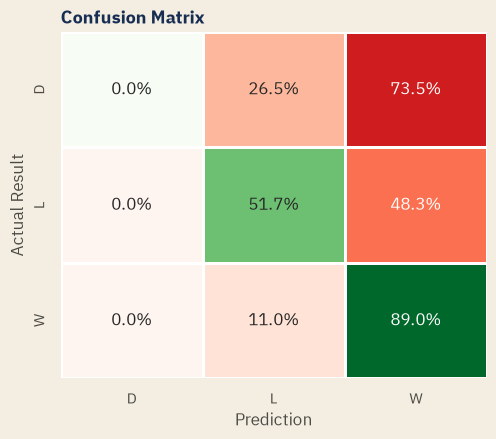

In [19]:
fig, ax = plt.subplots(figsize = (5.5,4.5))

common = dict(vmin = 0, vmax = 1, annot = True, fmt = '.1%',cbar = False,
              linewidths = 2,linecolor = 'white',ax = ax)


sns.heatmap(ct,mask = ~diag, cmap = 'Greens',**common)
sns.heatmap(ct,mask = diag, cmap = 'Reds',**common)
plt.xlabel('Prediction')
plt.ylabel('Actual Result')
plt.title('Confusion Matrix')

